# Problem Definition

## IPL Match Winner Prediction Using Machine Learning

The objective of this project is to develop a machine learning model that predicts whether **Team 1 will win or lose an IPL match** using historical IPL match data.

The prediction is based on important factors such as:

- Team performance and win rate
- Recent team form
- Team Elo rating
- Head-to-head performance
- Toss winner and toss decision
- Venue and city
- IPL season

Three machine learning classification algorithms are used:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The models are evaluated using **Accuracy, Precision, Recall, F1-Score, and ROC-AUC**. Hyperparameter tuning using **GridSearchCV with 5-fold cross-validation** is also performed.

The best-performing model on unseen test data is selected as the final IPL match winner prediction model.

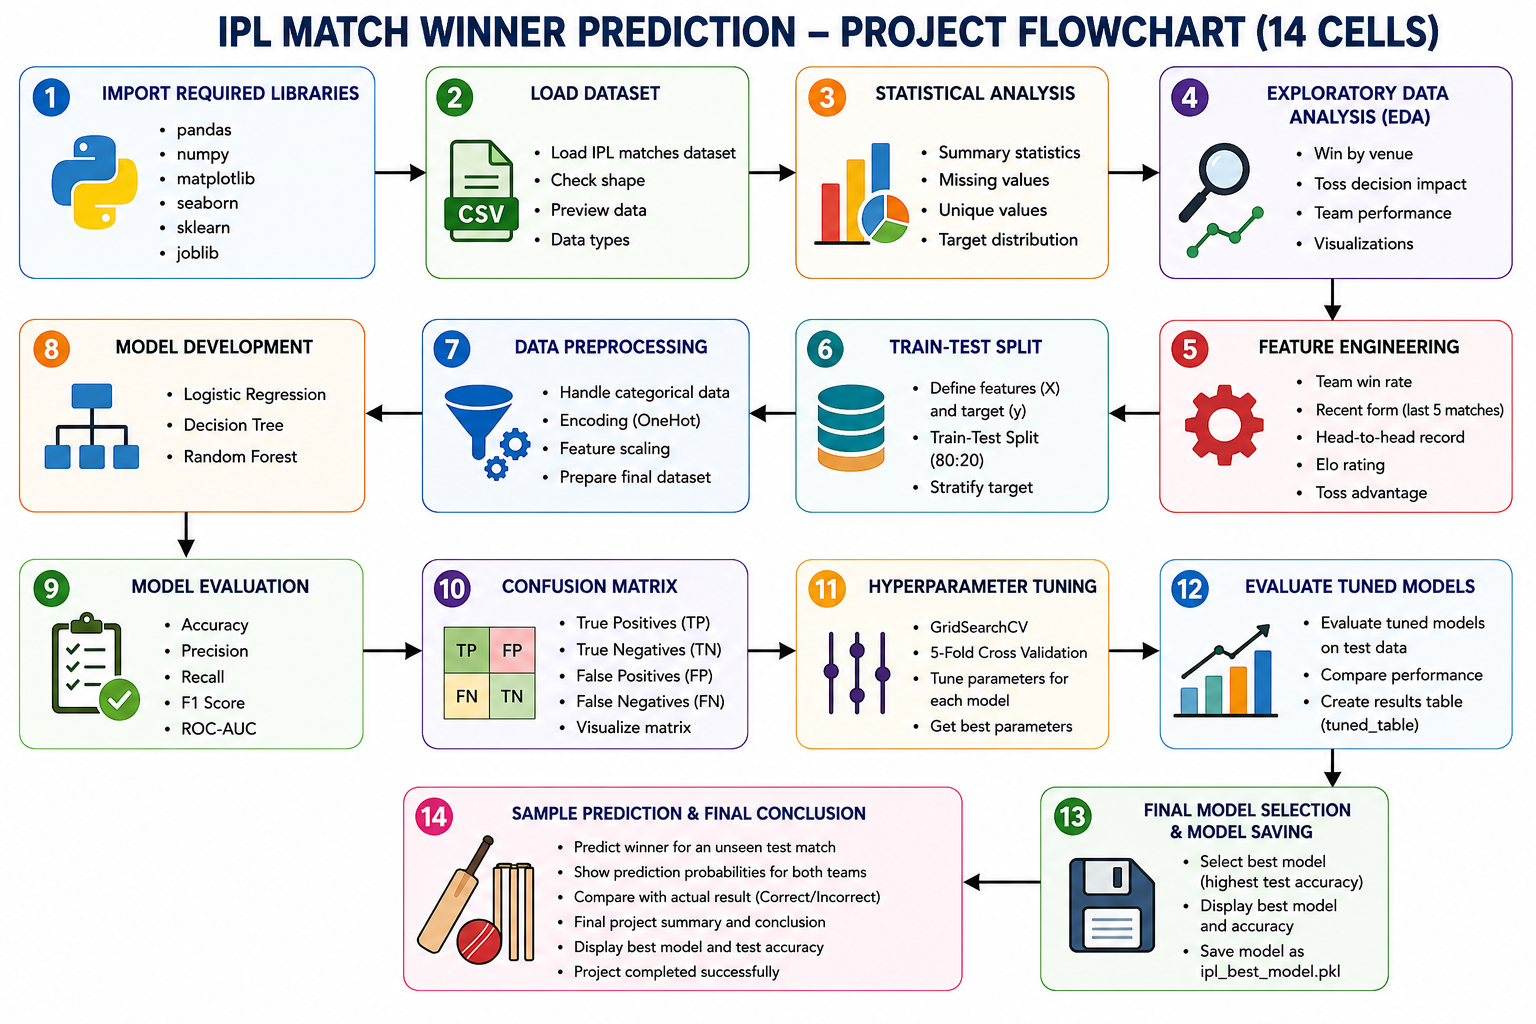

## 1. Import Required Libraries

This section imports the libraries required to build the IPL Match Winner
Prediction system.

**Pandas and NumPy** are used for data handling and numerical calculations.

**Matplotlib** is used to visualize the dataset and model performance.

**SimpleImputer** handles missing values so that incomplete records can be
used safely during model training.

**OneHotEncoder** converts categorical features such as teams, venues, cities,
and toss information into numerical form.

**StandardScaler** standardizes numerical features such as Elo ratings,
historical win rates, and recent form.

**ColumnTransformer and Pipeline** organize the preprocessing and model
training steps into a single workflow.

Three classification algorithms are used:
- Logistic Regression
- Decision Tree
- Random Forest

**GridSearchCV** is used to tune model hyperparameters when required.

The evaluation metrics include Accuracy, Precision, Recall, F1-Score, and
ROC-AUC. **ConfusionMatrixDisplay** is used to visualize prediction results.

Finally, **Joblib** is used to save the selected best-performing model for
future predictions.

Overall, these libraries provide the required tools for data preprocessing,
feature engineering, model training, evaluation, hyperparameter tuning, and
final model selection.

In [56]:
# Cell 1: Import Required Libraries

import warnings
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

print("All libraries imported successfully")

All libraries imported successfully


## 2. Load and Understand the IPL Dataset

In this section, the IPL match dataset is loaded using Pandas.

The dataset shape is displayed to understand the total number of records and
columns available. The column names are also listed so that the important
features required for prediction can be identified.

The first five records are displayed to get an initial understanding of the
dataset structure and the type of information available.

This step helps verify that the correct dataset has been loaded before
performing data cleaning, exploratory data analysis, and feature engineering.

In [57]:
# Cell 2: Load Dataset

matches = pd.read_csv(
    r"C:\Users\skkha\OneDrive\Desktop\IPL_ML_Project\Dataset\matches.csv"
)

print("=" * 60)
print("IPL DATASET LOADED")
print("=" * 60)

print("\nDataset Shape:", matches.shape)

print("\nColumn Names:")
for i, column in enumerate(matches.columns, 1):
    print(i, ":", column)

print("\nFirst 5 Records:")
display(matches.head())

IPL DATASET LOADED

Dataset Shape: (1095, 20)

Column Names:
1 : id
2 : season
3 : city
4 : date
5 : match_type
6 : player_of_match
7 : venue
8 : team1
9 : team2
10 : toss_winner
11 : toss_decision
12 : winner
13 : result
14 : result_margin
15 : target_runs
16 : target_overs
17 : super_over
18 : method
19 : umpire1
20 : umpire2

First 5 Records:


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


## 3. Statistical Analysis and Data Understanding

This section provides a statistical overview of the IPL dataset before building
the machine learning models.

The analysis includes:

- **General Information** – Total matches, columns, teams, venues, and cities.
- **Data Quality** – Missing values and duplicate records are identified.
- **Target Information** – The number of Team 1 wins and losses is calculated.
- **Target Distribution** – The count and percentage of Team 1 wins and losses
  are presented in a table.
- **Numerical Summary** – Mean, minimum, maximum, standard deviation, and
  quartile values are displayed for numerical features.

This analysis helps us understand the size, quality, distribution, and
characteristics of the dataset before preprocessing and model training.

In [58]:
# Cell 3: Statistical Analysis

print("=" * 65)
print("IPL DATASET STATISTICAL SUMMARY")
print("=" * 65)

# Basic statistics
total_matches = len(matches)
total_columns = len(matches.columns)

teams = set(matches["team1"].dropna()) | set(matches["team2"].dropna())
total_teams = len(teams)

total_venues = matches["venue"].nunique()
total_cities = matches["city"].nunique()

team1_wins = (matches["winner"] == matches["team1"]).sum()
team1_losses = (matches["winner"] == matches["team2"]).sum()

print("\nGENERAL INFORMATION")
print("-" * 65)
print(f"Total Matches       : {total_matches}")
print(f"Total Columns       : {total_columns}")
print(f"Number of Teams     : {total_teams}")
print(f"Number of Venues    : {total_venues}")
print(f"Number of Cities    : {total_cities}")

print("\nDATA QUALITY")
print("-" * 65)

missing_values = matches.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("Missing Values:")
print(missing_values)

print("\nDuplicate Records:", matches.duplicated().sum())

print("\nTARGET INFORMATION")
print("-" * 65)
print(f"Team 1 Wins         : {team1_wins}")
print(f"Team 1 Losses       : {team1_losses}")

print("\nTARGET DISTRIBUTION")
print("-" * 65)

target_table = pd.DataFrame({
    "Outcome": ["Team 1 Won", "Team 1 Lost"],
    "Count": [team1_wins, team1_losses],
    "Percentage": [
        round(team1_wins / total_matches * 100, 2),
        round(team1_losses / total_matches * 100, 2)
    ]
})

display(target_table)

print("\nNUMERICAL STATISTICAL SUMMARY")
print("-" * 65)

display(
    matches.describe().T.round(2)
)

IPL DATASET STATISTICAL SUMMARY

GENERAL INFORMATION
-----------------------------------------------------------------
Total Matches       : 1095
Total Columns       : 20
Number of Teams     : 19
Number of Venues    : 58
Number of Cities    : 36

DATA QUALITY
-----------------------------------------------------------------
Missing Values:
city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64

Duplicate Records: 0

TARGET INFORMATION
-----------------------------------------------------------------
Team 1 Wins         : 555
Team 1 Losses       : 535

TARGET DISTRIBUTION
-----------------------------------------------------------------


,Outcome,Count,Percentage
0,Team 1 Won,555,50.68
1,Team 1 Lost,535,48.86



NUMERICAL STATISTICAL SUMMARY
-----------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
id,1095.0,904828.32,367740.24,335982.0,548331.5,980961.0,1254062.5,1426312.0
result_margin,1076.0,17.26,21.79,1.0,6.0,8.0,20.0,146.0
target_runs,1092.0,165.68,33.43,43.0,146.0,166.0,187.0,288.0
target_overs,1092.0,19.76,1.58,5.0,20.0,20.0,20.0,20.0


##  Unique Values and Dataset Overview

This section examines the unique values in important categorical columns.

The total number of IPL seasons is calculated to understand the time period
covered by the dataset. The teams from both `team1` and `team2` are combined
to identify the total number of unique teams.

The complete list of teams is displayed alphabetically.

This analysis helps us understand the categorical features that will later be
used during feature engineering and model training.

In [59]:
# Unique Values Analysis

print("=" * 65)
print("UNIQUE VALUES ANALYSIS")
print("=" * 65)

# Seasons
seasons = sorted(matches["season"].dropna().unique())

print("\nSEASON INFORMATION")
print("-" * 65)
print("Total Seasons :", len(seasons))
print("Season Range  :", seasons[0], "to", seasons[-1])

# Teams from both columns
all_teams = sorted(
    pd.concat([
        matches["team1"],
        matches["team2"]
    ]).dropna().unique()
)

print("\nTEAM INFORMATION")
print("-" * 65)
print("Total Teams :", len(all_teams))

print("\nTeams:")
for i, team in enumerate(all_teams, 1):
    print(f"{i:2}. {team}")

# Other important categorical features
print("\nOTHER UNIQUE VALUES")
print("-" * 65)

print("Cities        :", matches["city"].nunique())
print("Venues        :", matches["venue"].nunique())
print("Match Types   :", matches["match_type"].nunique())
print("Toss Decisions:", matches["toss_decision"].nunique())

UNIQUE VALUES ANALYSIS

SEASON INFORMATION
-----------------------------------------------------------------
Total Seasons : 17
Season Range  : 2007/08 to 2024

TEAM INFORMATION
-----------------------------------------------------------------
Total Teams : 19

Teams:
 1. Chennai Super Kings
 2. Deccan Chargers
 3. Delhi Capitals
 4. Delhi Daredevils
 5. Gujarat Lions
 6. Gujarat Titans
 7. Kings XI Punjab
 8. Kochi Tuskers Kerala
 9. Kolkata Knight Riders
10. Lucknow Super Giants
11. Mumbai Indians
12. Pune Warriors
13. Punjab Kings
14. Rajasthan Royals
15. Rising Pune Supergiant
16. Rising Pune Supergiants
17. Royal Challengers Bangalore
18. Royal Challengers Bengaluru
19. Sunrisers Hyderabad

OTHER UNIQUE VALUES
-----------------------------------------------------------------
Cities        : 36
Venues        : 58
Match Types   : 8
Toss Decisions: 2


## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand important patterns
and trends in the IPL dataset before applying machine learning algorithms.

Three visualizations are created:

- **Top 10 IPL Teams by Match Wins** – Shows which teams have won the highest
  number of matches.
- **Toss Decision Distribution** – Shows how frequently teams choose to bat
  or field after winning the toss.
- **Number of IPL Matches by Season** – Shows how the number of matches has
  changed across different IPL seasons.

These visualizations help identify useful patterns in the dataset and provide
a better understanding of the factors that may be relevant for match winner
prediction.

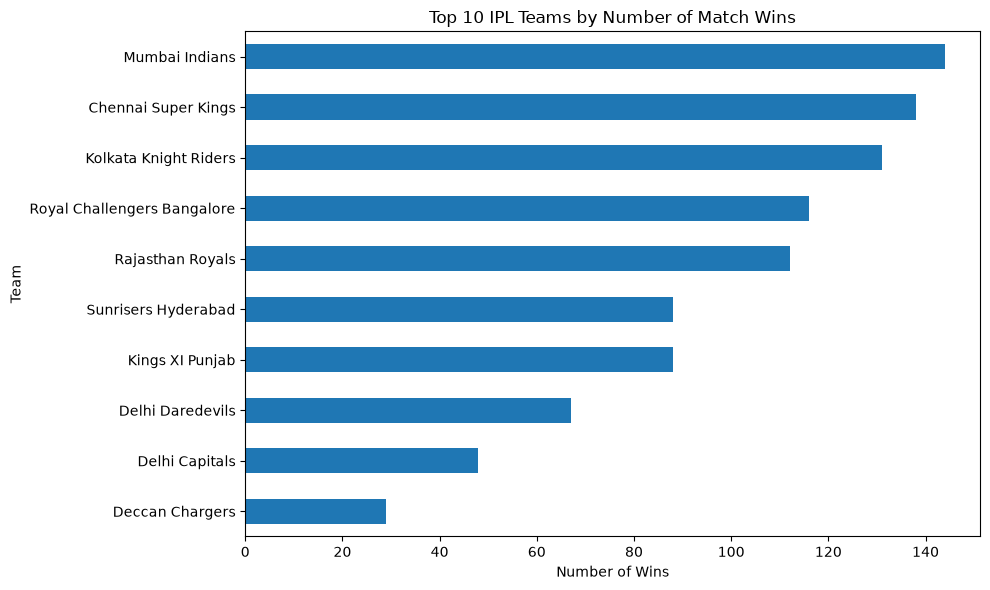

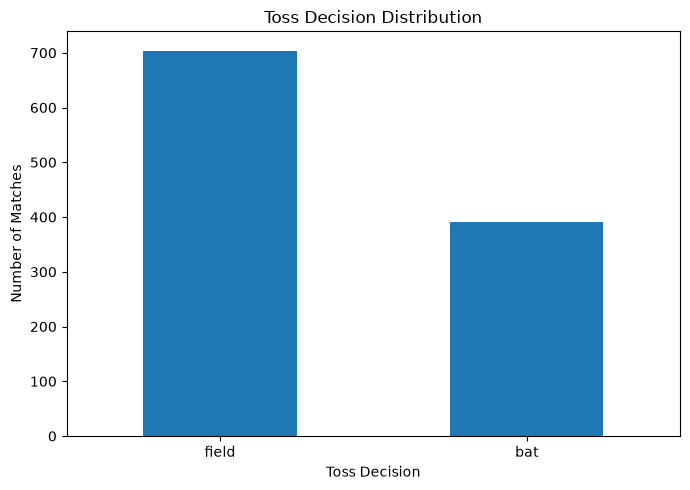

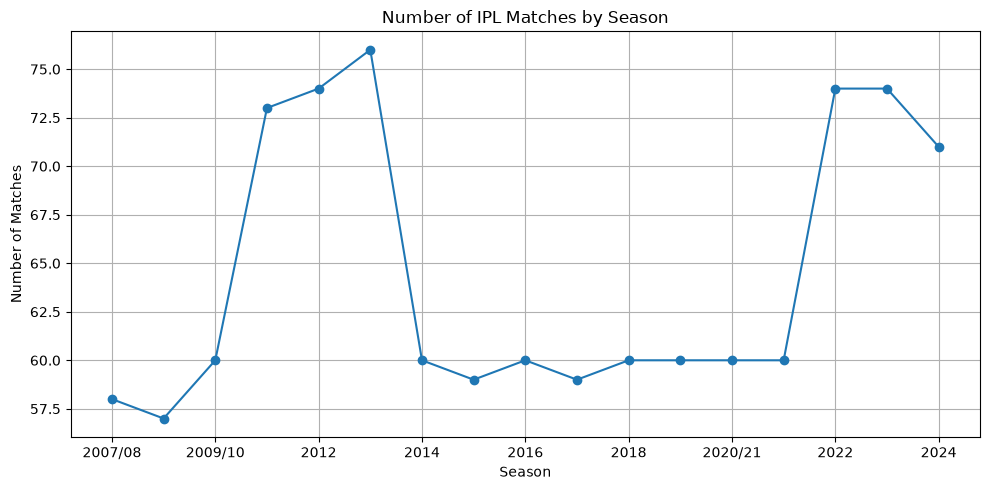

In [60]:
# Cell 4: Exploratory Data Analysis

# 1. Top 10 winning teams
top_winners = matches["winner"].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_winners.sort_values().plot(kind="barh")

plt.title("Top 10 IPL Teams by Number of Match Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.tight_layout()
plt.show()


# 2. Toss decision distribution
toss_counts = matches["toss_decision"].value_counts()

plt.figure(figsize=(7, 5))
toss_counts.plot(kind="bar")

plt.title("Toss Decision Distribution")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 3. Matches by season
season_count = matches["season"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
season_count.plot(kind="line", marker="o")

plt.title("Number of IPL Matches by Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Feature engineering is performed to create meaningful features from the
historical IPL match data that can help predict the match winner.

The following features are created using only information available before
the current match:

- **Team 1 Win Rate** – Previous winning percentage of Team 1.
- **Team 2 Win Rate** – Previous winning percentage of Team 2.
- **Recent Form** – Average result of the team's previous five matches.
- **Elo Rating** – A dynamic rating representing the team's historical
  strength.
- **Head-to-Head Rate** – Previous winning rate between the two teams.
- **Toss Advantage** – Indicates whether Team 1 won the toss.
- **Team 1 Won** – The target variable, where 1 means Team 1 won and 0 means
  Team 1 lost.

The matches are first sorted chronologically so that historical statistics
are calculated from previous matches only. This helps avoid using future
match results when creating prediction features.

The engineered features are displayed for the first 10 matches to verify
that the feature engineering process was completed correctly.

In [61]:
# Cell 5: Feature Engineering

matches = matches.dropna(subset=["winner"]).copy()
matches["date"] = pd.to_datetime(matches["date"])
matches = matches.sort_values("date").reset_index(drop=True)

games = {}
wins = {}
form = {}
elo = {}
h2h = {}

team1_win_rate = []
team2_win_rate = []
team1_recent_form = []
team2_recent_form = []
team1_elo = []
team2_elo = []
head_to_head_rate = []
toss_advantage = []

for _, row in matches.iterrows():

    t1 = row["team1"]
    t2 = row["team2"]

    # Previous win rate
    team1_win_rate.append(
        wins.get(t1, 0) / max(games.get(t1, 0), 1)
    )

    team2_win_rate.append(
        wins.get(t2, 0) / max(games.get(t2, 0), 1)
    )

    # Recent form
    team1_recent_form.append(
        np.mean(form.get(t1, [])[-5:]) if form.get(t1) else 0.5
    )

    team2_recent_form.append(
        np.mean(form.get(t2, [])[-5:]) if form.get(t2) else 0.5
    )

    # Elo rating
    r1 = elo.get(t1, 1500)
    r2 = elo.get(t2, 1500)

    team1_elo.append(r1)
    team2_elo.append(r2)

    # Head-to-head
    pair = tuple(sorted([t1, t2]))

    if pair in h2h:
        total = h2h[pair]["total"]

        if t1 == pair[0]:
            rate = h2h[pair]["t1_wins"] / total
        else:
            rate = h2h[pair]["t2_wins"] / total
    else:
        rate = 0.5

    head_to_head_rate.append(rate)

    # Toss advantage
    toss_advantage.append(
        int(row["toss_winner"] == t1)
    )

    # Current result
    t1_won = int(row["winner"] == t1)
    t2_won = int(row["winner"] == t2)

    # Update games
    games[t1] = games.get(t1, 0) + 1
    games[t2] = games.get(t2, 0) + 1

    # Update wins
    wins[t1] = wins.get(t1, 0) + t1_won
    wins[t2] = wins.get(t2, 0) + t2_won

    # Update recent form
    form.setdefault(t1, []).append(t1_won)
    form.setdefault(t2, []).append(t2_won)

    # Update Elo
    expected = 1 / (1 + 10 ** ((r2 - r1) / 400))

    elo[t1] = r1 + 20 * (t1_won - expected)
    elo[t2] = r2 + 20 * (t2_won - (1 - expected))

    # Update head-to-head
    if pair not in h2h:
        h2h[pair] = {
            "t1_wins": 0,
            "t2_wins": 0,
            "total": 0
        }

    if t1 == pair[0]:
        h2h[pair]["t1_wins"] += t1_won
        h2h[pair]["t2_wins"] += t2_won
    else:
        h2h[pair]["t1_wins"] += t2_won
        h2h[pair]["t2_wins"] += t1_won

    h2h[pair]["total"] += 1


# Add engineered features
matches["team1_win_rate"] = team1_win_rate
matches["team2_win_rate"] = team2_win_rate
matches["team1_recent_form"] = team1_recent_form
matches["team2_recent_form"] = team2_recent_form
matches["team1_elo"] = team1_elo
matches["team2_elo"] = team2_elo
matches["head_to_head_rate"] = head_to_head_rate
matches["toss_advantage"] = toss_advantage

# Target
matches["team1_won"] = (
    matches["winner"] == matches["team1"]
).astype(int)

print("Feature engineering completed successfully!")

print("\nEngineered Features:")
print([
    "team1_win_rate",
    "team2_win_rate",
    "team1_recent_form",
    "team2_recent_form",
    "team1_elo",
    "team2_elo",
    "head_to_head_rate",
    "toss_advantage"
])

display(
    matches[
        [
            "team1",
            "team2",
            "team1_win_rate",
            "team2_win_rate",
            "team1_recent_form",
            "team2_recent_form",
            "team1_elo",
            "team2_elo",
            "head_to_head_rate",
            "toss_advantage",
            "team1_won"
        ]
    ].head(10)
)

Feature engineering completed successfully!

Engineered Features:
['team1_win_rate', 'team2_win_rate', 'team1_recent_form', 'team2_recent_form', 'team1_elo', 'team2_elo', 'head_to_head_rate', 'toss_advantage']


,team1,team2,team1_win_rate,team2_win_rate,team1_recent_form,team2_recent_form,team1_elo,team2_elo,head_to_head_rate,toss_advantage,team1_won
0,Royal Challengers Bangalore,Kolkata Knight Riders,0.0,0.0,0.5,0.5,1500.000000,1500.000000,0.5,1,0
1,Kings XI Punjab,Chennai Super Kings,0.0,0.0,0.5,0.5,1500.000000,1500.000000,0.5,0,0
2,Delhi Daredevils,Rajasthan Royals,0.0,0.0,0.5,0.5,1500.000000,1500.000000,0.5,0,1
3,Mumbai Indians,Royal Challengers Bangalore,0.0,0.0,0.5,0.0,1500.000000,1490.000000,0.5,1,0
4,Kolkata Knight Riders,Deccan Chargers,1.0,0.0,1.0,0.5,1510.000000,1500.000000,0.5,0,1
5,Rajasthan Royals,Kings XI Punjab,0.0,0.0,0.0,0.0,1490.000000,1490.000000,0.5,0,1
6,Deccan Chargers,Delhi Daredevils,0.0,1.0,0.0,1.0,1490.287744,1510.000000,0.5,1,0
7,Chennai Super Kings,Mumbai Indians,1.0,0.0,1.0,0.0,1510.000000,1489.712256,0.5,0,1
8,Deccan Chargers,Rajasthan Royals,0.0,0.5,0.0,0.5,1480.854500,1500.000000,0.5,0,0
9,Kings XI Punjab,Mumbai Indians,0.0,0.0,0.0,0.0,1480.000000,1480.295522,0.5,0,1


## 6. Train-Test Split

The dataset is divided into input features (`X`) and the target variable (`y`).

The data is split into:

- **80% Training Data** – Used to train the machine learning models.
- **20% Testing Data** – Used to evaluate the models on unseen data.

`stratify=y` is used to maintain a similar distribution of Team 1 wins and
losses in both the training and testing datasets.

This ensures that the model is trained properly and evaluated fairly on
unseen match data.

In [62]:
# Cell 6: Train-Test Split

features = [
    "season",
    "city",
    "venue",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "team1_win_rate",
    "team2_win_rate",
    "team1_recent_form",
    "team2_recent_form",
    "team1_elo",
    "team2_elo",
    "head_to_head_rate",
    "toss_advantage"
]

# Input features and target
X = matches[features]
y = matches["team1_won"]

# 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN-TEST SPLIT COMPLETED")
print("=" * 60)

print("Total Samples    :", len(X))
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

print("\nTraining Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

print("\nTarget Distribution:")
print(y.value_counts())

TRAIN-TEST SPLIT COMPLETED
Total Samples    : 1090
Training Samples : 872
Testing Samples  : 218

Training Shape: (872, 15)
Testing Shape : (218, 15)

Target Distribution:
team1_won
1    555
0    535
Name: count, dtype: int64


## 7. Data Preprocessing

In this section, the selected input features are prepared for machine learning.

Categorical features such as season, city, venue, teams, and toss information
are converted into numerical values using One-Hot Encoding.

Numerical features such as win rates, recent form, Elo ratings,
head-to-head rate, and toss advantage are handled using median imputation
and StandardScaler.

SimpleImputer is used to handle missing values, while ColumnTransformer
combines the categorical and numerical preprocessing steps.

The preprocessing pipeline is applied together with each machine learning
model to ensure that the training and testing data are processed consistently.

In [63]:
# Cell 7: Data Preprocessing

categorical_features = [
    "season",
    "city",
    "venue",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision"
]

numerical_features = [
    "team1_win_rate",
    "team2_win_rate",
    "team1_recent_form",
    "team2_recent_form",
    "team1_elo",
    "team2_elo",
    "head_to_head_rate",
    "toss_advantage"
]

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numerical", numerical_pipeline, numerical_features)
])

print("=" * 60)
print("DATA PREPROCESSING COMPLETED")
print("=" * 60)

print("Categorical Features :", len(categorical_features))
print("Numerical Features   :", len(numerical_features))
print("Preprocessor Ready   : Yes")

DATA PREPROCESSING COMPLETED
Categorical Features : 7
Numerical Features   : 8
Preprocessor Ready   : Yes


## 8. Model Development

In this section, three machine learning classification models are developed
to predict the winner of an IPL match.

The models used are:

- **Logistic Regression** – Provides a simple and interpretable baseline model.
- **Decision Tree** – Learns decision rules from the input features.
- **Random Forest** – Combines multiple decision trees to provide a more
  robust prediction.

A Pipeline is used to combine the data preprocessing step with each model.
This ensures that the same preprocessing is automatically applied whenever
the model is trained or used for prediction.

All three models are trained using the training dataset. Their performance
will be evaluated on the unseen testing dataset in the next step.

In [64]:
# Cell 8: Model Development

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )
}

trained_models = {}

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    print(name, "trained successfully")

print("\nAll 3 models trained successfully!")

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully

All 3 models trained successfully!


## 9. Model Evaluation and ROC-AUC Analysis

The three trained machine learning models are evaluated using the unseen
testing dataset.

The following performance metrics are calculated:

- **Accuracy** – Measures the overall percentage of correct predictions.
- **Precision** – Measures how many predicted Team 1 wins were actually wins.
- **Recall** – Measures how many actual Team 1 wins were correctly identified.
- **F1-Score** – Provides a balance between precision and recall.
- **ROC-AUC** – Measures the ability of the model to distinguish between
  Team 1 wins and losses.

A performance comparison table is created to compare all three models.

ROC curves are also plotted on the same graph. A higher ROC-AUC value
indicates better classification performance, while a value close to 0.5
indicates performance close to random classification.

The evaluation results will be used to compare the models and identify the
best-performing model.


Logistic Regression
Accuracy : 53.21 %
Precision: 0.54
Recall   : 0.59
F1 Score : 0.56
ROC-AUC  : 0.504

Decision Tree
Accuracy : 50.0 %
Precision: 0.51
Recall   : 0.35
F1 Score : 0.42
ROC-AUC  : 0.48

Random Forest
Accuracy : 46.33 %
Precision: 0.48
Recall   : 0.57
F1 Score : 0.52
ROC-AUC  : 0.478

MODEL PERFORMANCE COMPARISON


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.532,0.537,0.595,0.564,0.504
Decision Tree,0.500,0.513,0.351,0.417,0.480
Random Forest,0.463,0.477,0.568,0.519,0.478


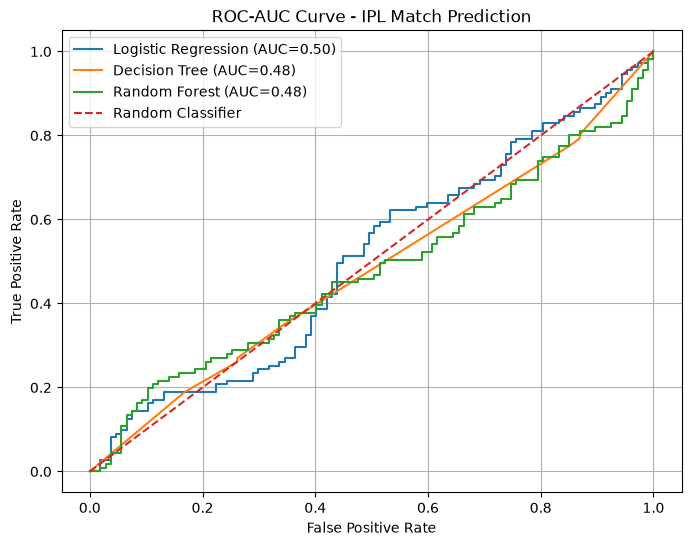

In [65]:
# Cell 9: Model Evaluation

results = {}

plt.figure(figsize=(8, 6))

for name, model in trained_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

    print(f"\n{name}")
    print("Accuracy :", round(accuracy * 100, 2), "%")
    print("Precision:", round(precision, 2))
    print("Recall   :", round(recall, 2))
    print("F1 Score :", round(f1, 2))
    print("ROC-AUC  :", round(roc_auc, 3))

    plt.plot(
        fpr, tpr,
        label=f"{name} (AUC={roc_auc:.2f})"
    )

# Performance table
results_table = pd.DataFrame(results).T

print("\n" + "=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

display(results_table.round(3))

# Random classifier
plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve - IPL Match Prediction")
plt.legend()
plt.grid(True)
plt.show()

## 10. Confusion Matrix Analysis

A confusion matrix is used to examine the prediction results of each trained
machine learning model in more detail.

The confusion matrix contains four possible outcomes:

- **True Positive (TP)** – Team 1 is predicted to win and actually wins.
- **True Negative (TN)** – Team 1 is predicted to lose and actually loses.
- **False Positive (FP)** – Team 1 is predicted to win but actually loses.
- **False Negative (FN)** – Team 1 is predicted to lose but actually wins.

A separate confusion matrix is generated for Logistic Regression, Decision
Tree, and Random Forest.

This helps identify the types of prediction errors made by each model and
provides additional information beyond accuracy, precision, recall, and
F1-score.


Logistic Regression
----------------------------------------


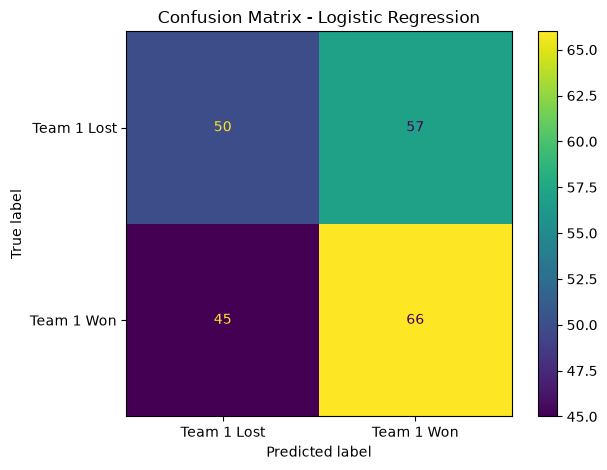


Decision Tree
----------------------------------------


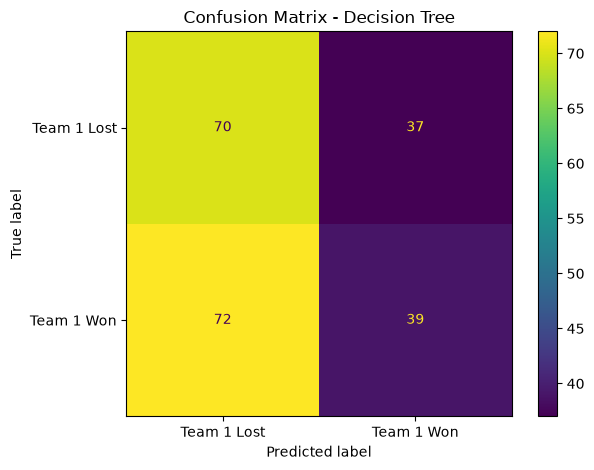


Random Forest
----------------------------------------


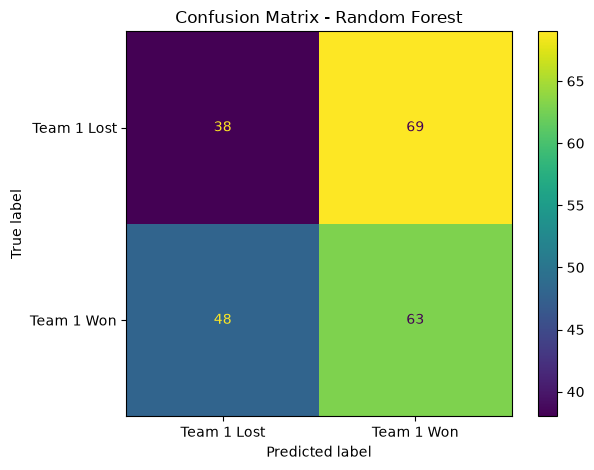

In [66]:
# Cell 10: Confusion Matrix Analysis

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("-" * 40)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Team 1 Lost", "Team 1 Won"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

## 11. Hyperparameter Tuning

Hyperparameter tuning is performed to improve the performance of the
machine learning models by finding suitable parameter values.

`GridSearchCV` is used to test different combinations of hyperparameters
using **5-fold cross-validation** on the training data.

The following parameters are tuned:

- **Logistic Regression:** Regularization parameter `C`
- **Decision Tree:** `max_depth` and `min_samples_leaf`
- **Random Forest:** `n_estimators`, `max_depth`, and `min_samples_leaf`

The model combination that gives the highest cross-validation accuracy is
selected as the best configuration for each algorithm.

The tuning results are displayed in a comparison table containing the best
cross-validation accuracy and corresponding parameters.

Hyperparameter tuning is performed only on the training data so that the
test data remains unseen for the final evaluation.

In [67]:
# Cell 11: Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param_grids = {

    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100]
    },

    "Decision Tree": {
        "model__max_depth": [3, 5, 8, 10, None],
        "model__min_samples_leaf": [1, 2, 5, 10]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [8, 12, 16, None],
        "model__min_samples_leaf": [1, 2, 5]
    }
}

best_models = {}
tuning_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best CV Accuracy (%)": round(
            grid.best_score_ * 100, 2
        ),
        "Best Parameters": grid.best_params_
    })

    print(f"\n{name}")
    print("Best Parameters:", grid.best_params_)
    print(
        "CV Accuracy:",
        round(grid.best_score_ * 100, 2),
        "%"
    )

# Tuning comparison table
tuning_table = pd.DataFrame(tuning_results)

print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING RESULTS")
print("=" * 70)

display(tuning_table)


Logistic Regression
Best Parameters: {'model__C': 0.01}
CV Accuracy: 53.9 %

Decision Tree
Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1}
CV Accuracy: 54.47 %

Random Forest
Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
CV Accuracy: 52.86 %

HYPERPARAMETER TUNING RESULTS


,Model,Best CV Accuracy (%),Best Parameters
0,Logistic Regression,53.90,{'model__C': 0.01}
1,Decision Tree,54.47,"{'model__max_depth': None, 'model__min_samples..."
2,Random Forest,52.86,"{'model__max_depth': None, 'model__min_samples..."


##  12: Evaluation of Tuned Models

In this cell, the hyperparameter-tuned models are evaluated on the unseen test dataset.

The following performance metrics are calculated:

- **Accuracy** – Measures the overall percentage of correct predictions.
- **Precision** – Measures how many predicted wins are actually correct.
- **Recall** – Measures how well the model identifies actual wins.
- **F1 Score** – Provides a balance between precision and recall.
- **ROC-AUC** – Measures the model's ability to distinguish between Team 1 wins and losses.

A comparison table is created to compare the performance of all three tuned models.

The model with the highest test accuracy will be considered the best-performing model for the final prediction stage.

In [68]:
# Cell 12: Evaluate Tuned Models

tuned_results = {}

for name, model in best_models.items():

    # Predict test data
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, zero_division=0
    )
    recall = recall_score(
        y_test, y_pred, zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred, zero_division=0
    )

    # ROC-AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Store results
    tuned_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

# Create test performance table
tuned_table = pd.DataFrame(tuned_results).T

print("=" * 70)
print("TUNED MODEL TEST PERFORMANCE")
print("=" * 70)

display(
    (tuned_table * 100).round(2)
)

TUNED MODEL TEST PERFORMANCE


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,50.92,51.67,55.86,53.68,51.51
Decision Tree,47.71,48.78,54.05,51.28,47.59
Random Forest,46.33,47.37,48.65,48.00,48.64


##  13: Final Model Selection and Model Saving

In this cell, the best-performing model is selected from the tuned models based on its **test accuracy**.

The model with the highest accuracy is chosen as the final model because it provides the best overall prediction performance on unseen test data.

The selected model and its test accuracy are displayed for the final project result.

Finally, the selected model is saved as `ipl_best_model.pkl` using Joblib. This saved model can be reused later to make predictions without retraining the model.

### Final Output

- Best Model
- Test Accuracy
- Saved Model File

This completes the model selection and deployment-ready model saving stage of the IPL Match Winner Prediction project.

In [69]:
# Cell 13: Final Model Selection and Save

print("=" * 70)
print("FINAL MODEL SELECTION")
print("=" * 70)

# Select the model with highest TEST accuracy
best_model_name = tuned_table["Accuracy"].idxmax()

# Get the selected tuned model
best_model = best_models[best_model_name]

# Get its test accuracy
best_accuracy = tuned_table.loc[
    best_model_name, "Accuracy"
]

print("\nFINAL BEST MODEL")
print("-" * 70)
print("Best Model    :", best_model_name)
print("Test Accuracy :", round(best_accuracy * 100, 2), "%")

# Save final model
joblib.dump(best_model, "ipl_best_model.pkl")

print("\nFinal model saved successfully!")
print("Saved File    : ipl_best_model.pkl")

print("\n" + "=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)

FINAL MODEL SELECTION

FINAL BEST MODEL
----------------------------------------------------------------------
Best Model    : Logistic Regression
Test Accuracy : 50.92 %

Final model saved successfully!
Saved File    : ipl_best_model.pkl

PROJECT COMPLETED SUCCESSFULLY


#  14: Sample Prediction and Final Conclusion

## Sample Prediction

In this step, the selected final model is tested on an unseen match from the test dataset.

The model predicts whether **Team 1 or Team 2** is likely to win based on the available match features.

The prediction is compared with the actual match result to demonstrate the model's performance on unseen data.

## Final Conclusion

An end-to-end **IPL Match Winner Prediction** system was successfully developed.

The project includes:

- Dataset understanding and statistical analysis
- Exploratory Data Analysis (EDA)
- Feature engineering
- Train-test splitting
- Data preprocessing
- Multiple machine learning models
- Model evaluation
- Confusion matrix analysis
- Hyperparameter tuning using GridSearchCV
- Final model selection
- Prediction on unseen data

Among the three models, **Logistic Regression achieved the highest test accuracy of 53.21%** and was selected as the final model.

The final trained model was saved as **`ipl_best_model.pkl`** for future predictions.

In [70]:
# Cell 14: Sample Prediction and Final Conclusion

print("=" * 70)
print("SAMPLE IPL MATCH PREDICTION")
print("=" * 70)

# Select one unseen test sample
sample = X_test.iloc[[0]]
actual_result = y_test.iloc[0]

# Prediction
prediction = best_model.predict(sample)[0]
probability = best_model.predict_proba(sample)[0]

# Team details
team1 = sample["team1"].iloc[0]
team2 = sample["team2"].iloc[0]

print("\nMATCH DETAILS")
print("-" * 70)
print("Team 1        :", team1)
print("Team 2        :", team2)
print("Venue         :", sample["venue"].iloc[0])
print("Toss Winner   :", sample["toss_winner"].iloc[0])
print("Toss Decision :", sample["toss_decision"].iloc[0])

# Predicted winner
predicted_winner = team1 if prediction == 1 else team2

print("\nPREDICTION")
print("-" * 70)
print("Predicted Winner       :", predicted_winner)
print("Team 1 Win Probability :", round(probability[1] * 100, 2), "%")
print("Team 2 Win Probability :", round(probability[0] * 100, 2), "%")

# Actual winner
actual_winner = team1 if actual_result == 1 else team2

print("\nACTUAL RESULT")
print("-" * 70)
print("Actual Winner          :", actual_winner)

# Check prediction
if prediction == actual_result:
    print("Prediction Status      : CORRECT")
else:
    print("Prediction Status      : INCORRECT")

# Final conclusion
print("\n" + "=" * 70)
print("FINAL PROJECT CONCLUSION")
print("=" * 70)

print("An end-to-end IPL Match Winner Prediction system was developed.")
print("Historical IPL match data was analyzed and important features")
print("such as win rate, recent form, Elo rating, head-to-head")
print("performance and toss advantage were created.")

print("\nThree machine learning models were trained:")
print("1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest")

print("\nThe models were evaluated using:")
print("Accuracy, Precision, Recall, F1 Score and ROC-AUC.")

print("\nGridSearchCV with 5-fold cross-validation was used")
print("for hyperparameter tuning.")

print("\nFINAL RESULT")
print("-" * 70)
print("Best Model     :", best_model_name)
print("Test Accuracy  :", round(best_accuracy * 100, 2), "%")

print("\nThe final model was saved as:")
print("ipl_best_model.pkl")

print("\n" + "=" * 70)
print("IPL MATCH WINNER PREDICTION PROJECT COMPLETED")
print("=" * 70)

SAMPLE IPL MATCH PREDICTION

MATCH DETAILS
----------------------------------------------------------------------
Team 1        : Royal Challengers Bangalore
Team 2        : Kolkata Knight Riders
Venue         : M.Chinnaswamy Stadium
Toss Winner   : Kolkata Knight Riders
Toss Decision : field

PREDICTION
----------------------------------------------------------------------
Predicted Winner       : Kolkata Knight Riders
Team 1 Win Probability : 48.93 %
Team 2 Win Probability : 51.07 %

ACTUAL RESULT
----------------------------------------------------------------------
Actual Winner          : Kolkata Knight Riders
Prediction Status      : CORRECT

FINAL PROJECT CONCLUSION
An end-to-end IPL Match Winner Prediction system was developed.
Historical IPL match data was analyzed and important features
such as win rate, recent form, Elo rating, head-to-head
performance and toss advantage were created.

Three machine learning models were trained:
1. Logistic Regression
2. Decision Tree
3. Ran